In [ ]:
!git clone https://github.com/HydnumRepandum/LLM-for-multilingual-consultation-feedback.git
%cd LLM-for-multilingual-consultation-feedback

Cloning into 'LLM-for-multilingual-consultation-feedback'...
remote: Enumerating objects: 389, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (211/211), done.
remote: Total 389 (delta 132), reused 19 (delta 19), pack-reused 158 (from 1)
Receiving objects: 100% (389/389), 36.94 MiB | 29.25 MiB/s, done.
Resolving deltas: 100% (174/174), done.
/content/LLM-for-multilingual-consultation-feedback/LLM-for-multilingual-consultation-feedback/LLM-for-multilingual-consultation-feedback/LLM-for-multilingual-consultation-feedback



--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/openai_imprescriptibility.xlsx ---
✅ Saved graph to: graphs_output/repartition_openai_imprescriptibility_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_openai_imprescriptibility_volet1_fr.png


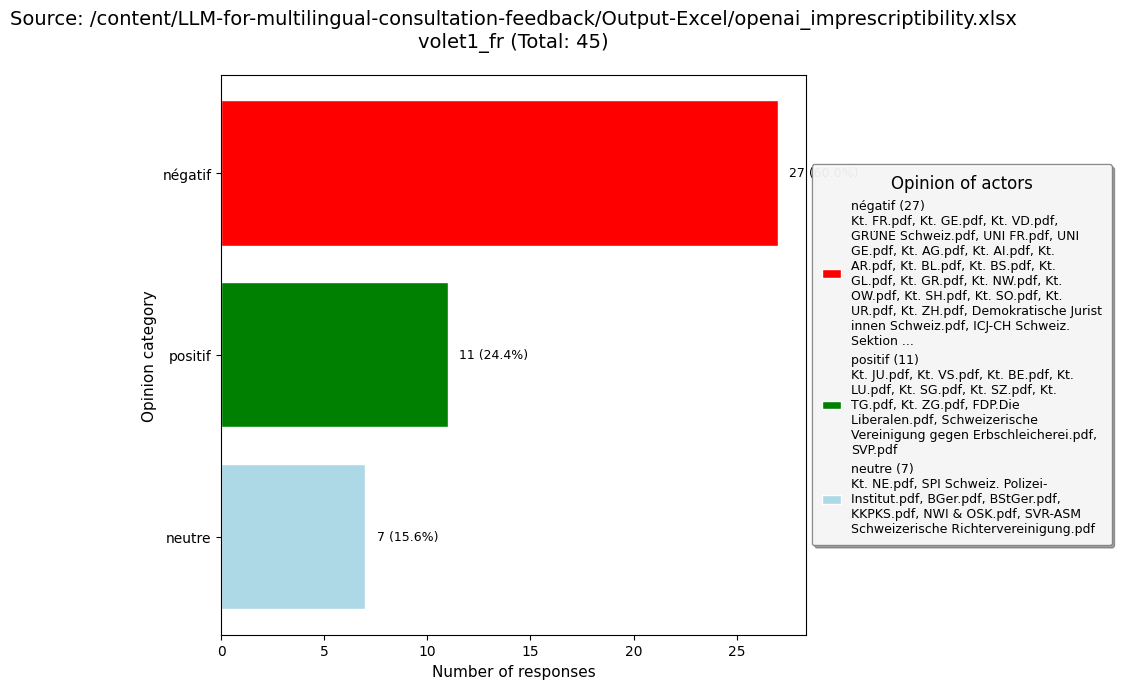


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/0_Imprescribility.xlsx ---
✅ Saved graph to: graphs_output/repartition_0_Imprescribility_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_0_Imprescribility_volet1_fr.png


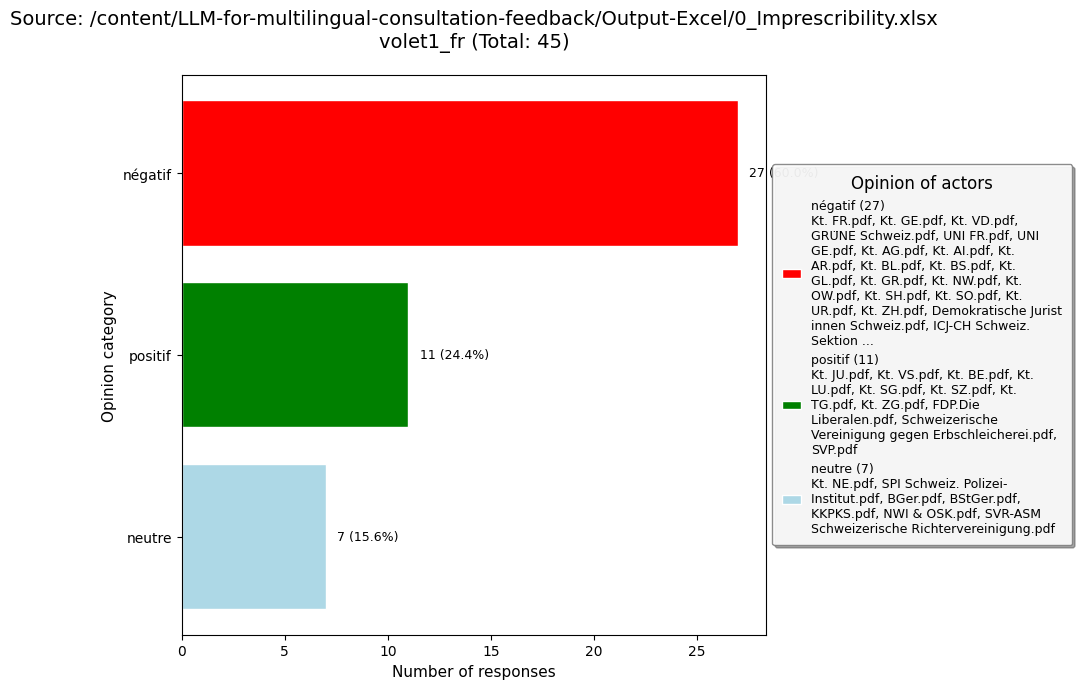


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/openai_interest.xlsx ---
✅ Saved graph to: graphs_output/repartition_openai_interest_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_openai_interest_volet1_fr.png


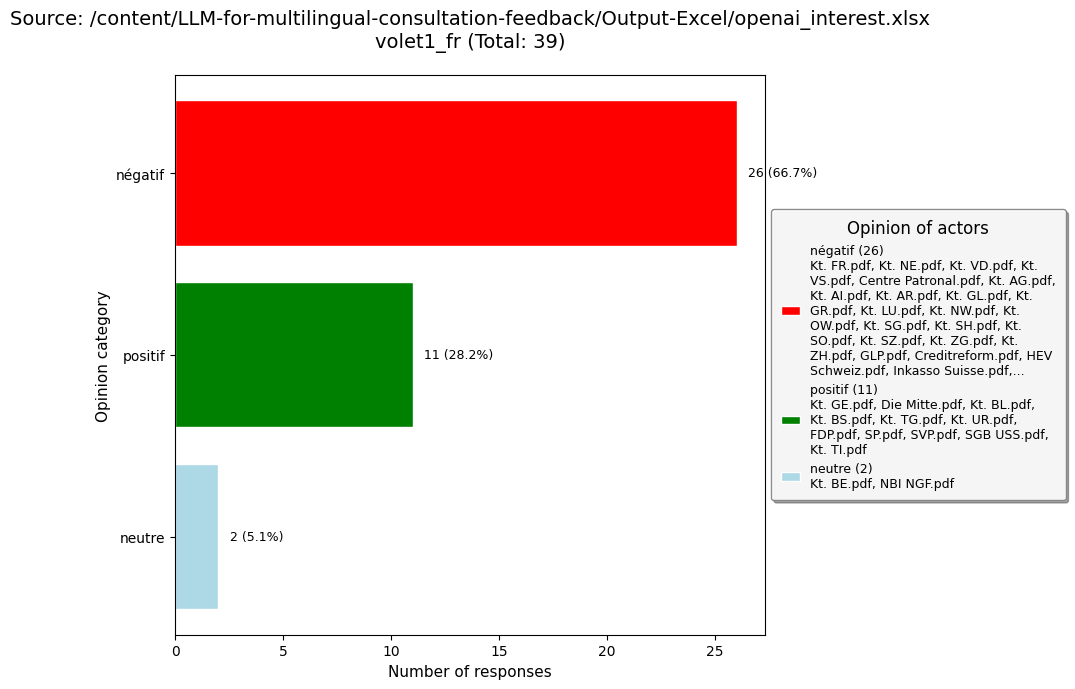

✅ Saved graph to: graphs_output/repartition_openai_interest_volet2_fr.pdf
✅ Saved graph to: graphs_output/repartition_openai_interest_volet2_fr.png


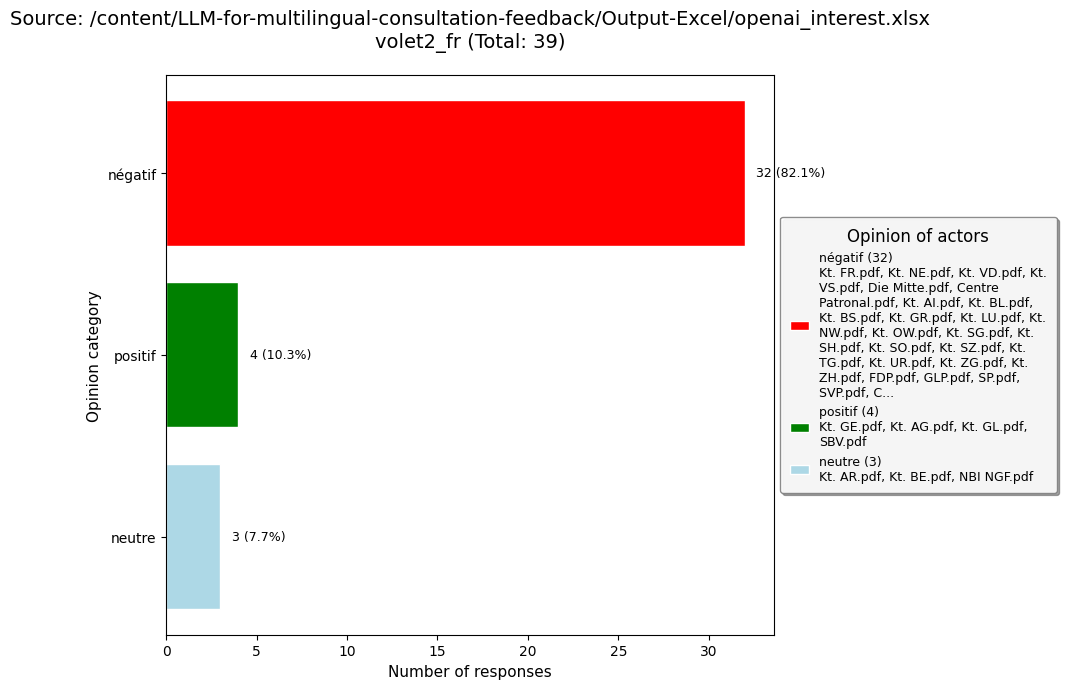


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/0.9ollama_douane.xlsx ---
  No recognized volet columns (['volet1_fr', 'volet2_fr']) found. Skipping.

--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/0.9ollama_intereset.xlsx ---
✅ Saved graph to: graphs_output/repartition_0.9ollama_intereset_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_0.9ollama_intereset_volet1_fr.png


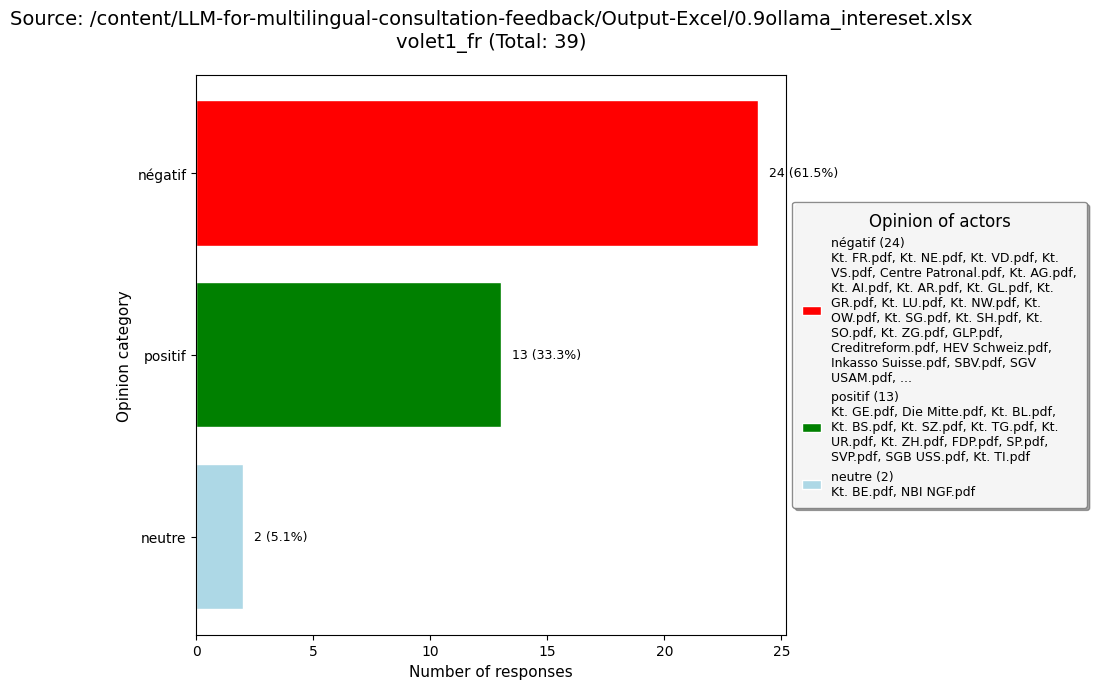

✅ Saved graph to: graphs_output/repartition_0.9ollama_intereset_volet2_fr.pdf
✅ Saved graph to: graphs_output/repartition_0.9ollama_intereset_volet2_fr.png


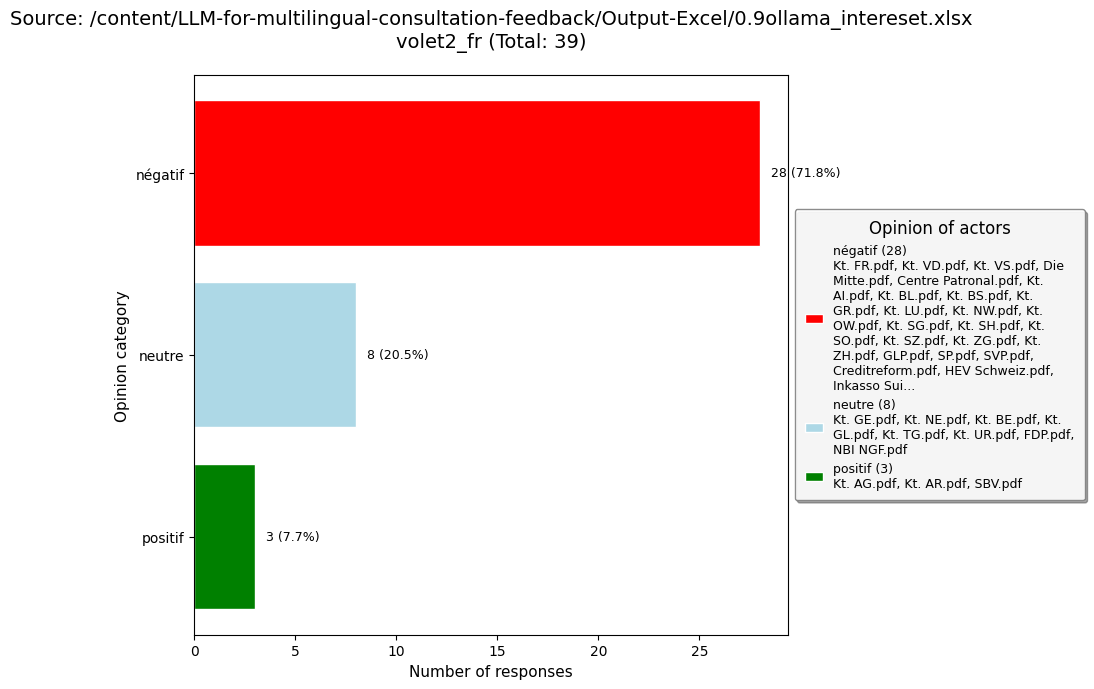


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/0.9ollama_impresctibility.xlsx ---
✅ Saved graph to: graphs_output/repartition_0.9ollama_impresctibility_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_0.9ollama_impresctibility_volet1_fr.png


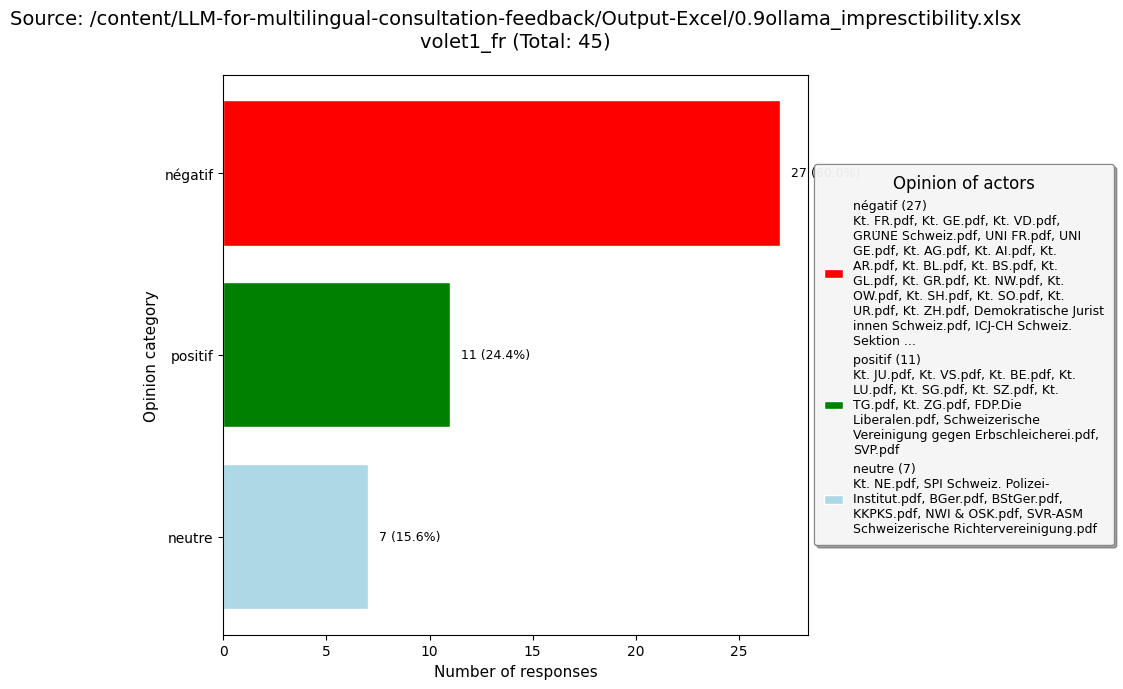


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/0_Moratorium_Interest_Rate.xlsx ---
✅ Saved graph to: graphs_output/repartition_0_Moratorium_Interest_Rate_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_0_Moratorium_Interest_Rate_volet1_fr.png


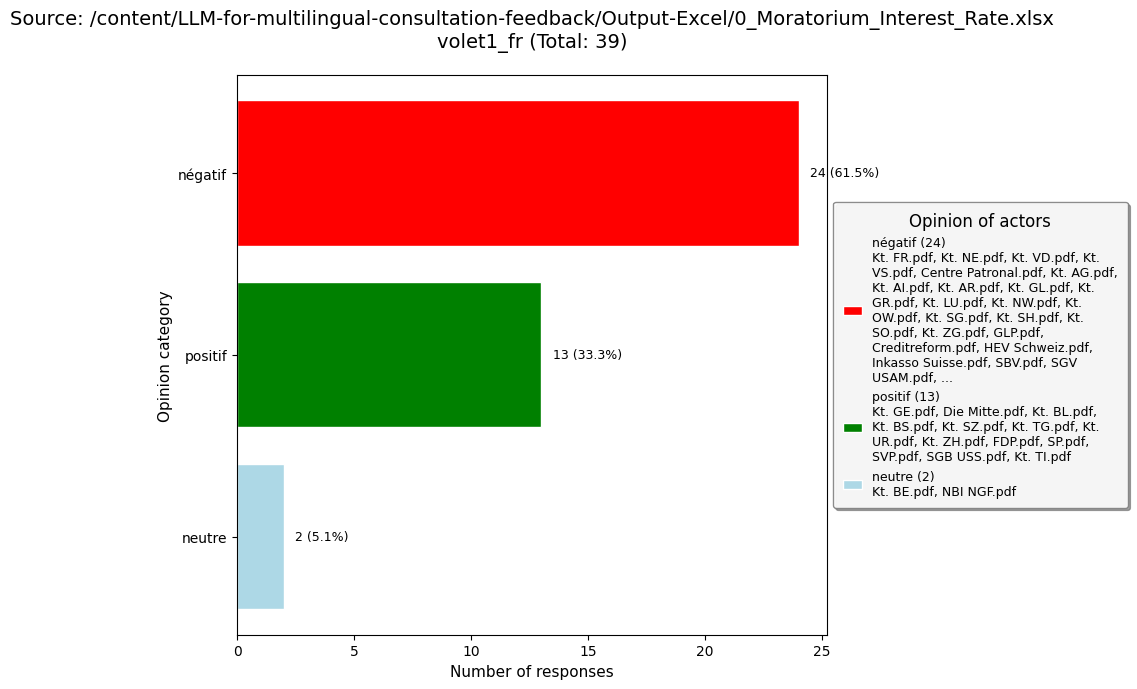

✅ Saved graph to: graphs_output/repartition_0_Moratorium_Interest_Rate_volet2_fr.pdf
✅ Saved graph to: graphs_output/repartition_0_Moratorium_Interest_Rate_volet2_fr.png


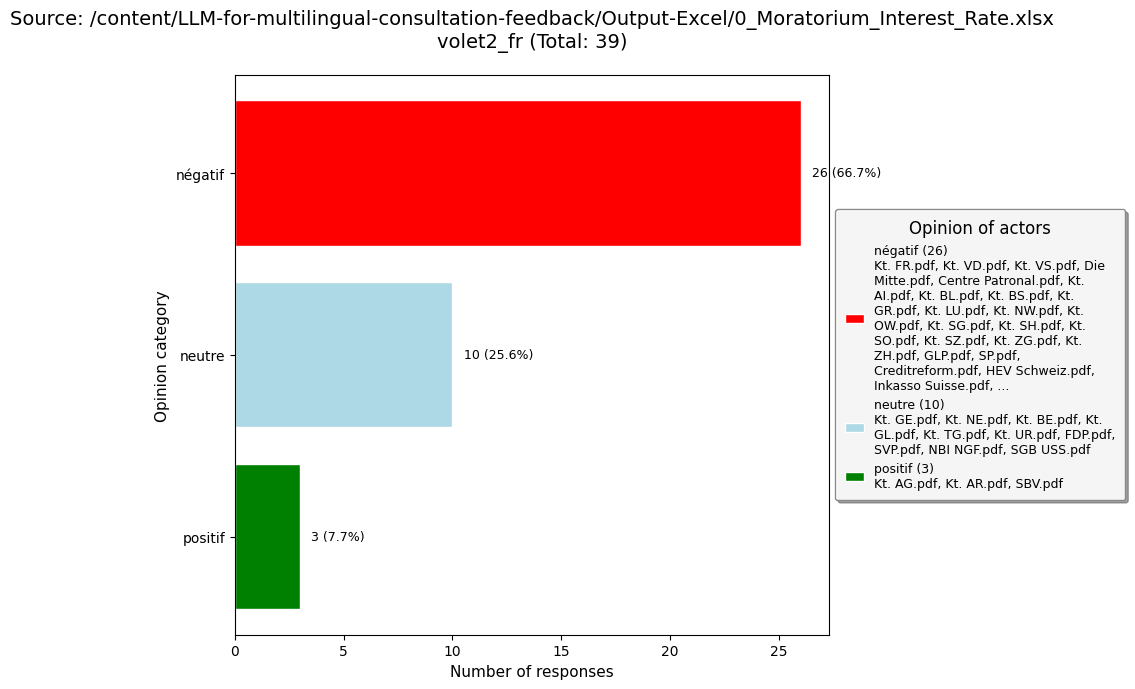


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/ 0_Import_Tax_Exemption.xlsx ---
✅ Saved graph to: graphs_output/repartition_ 0_Import_Tax_Exemption_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_ 0_Import_Tax_Exemption_volet1_fr.png


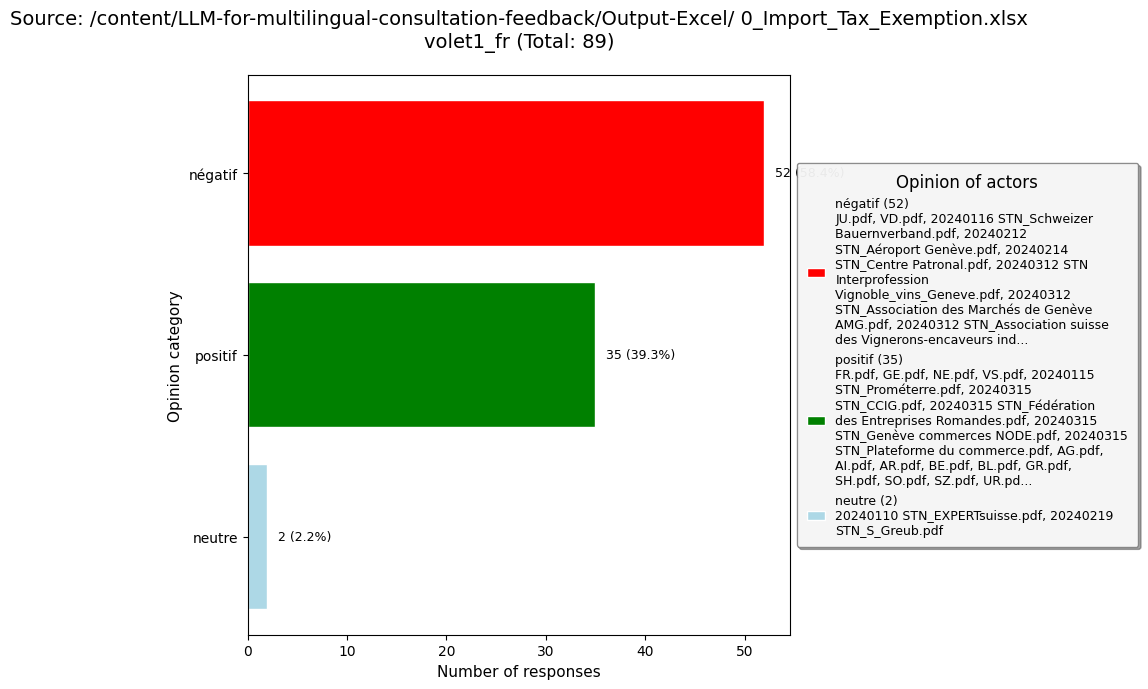


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/openai_douane.xlsx ---
✅ Saved graph to: graphs_output/repartition_openai_douane_volet1_fr.pdf
✅ Saved graph to: graphs_output/repartition_openai_douane_volet1_fr.png


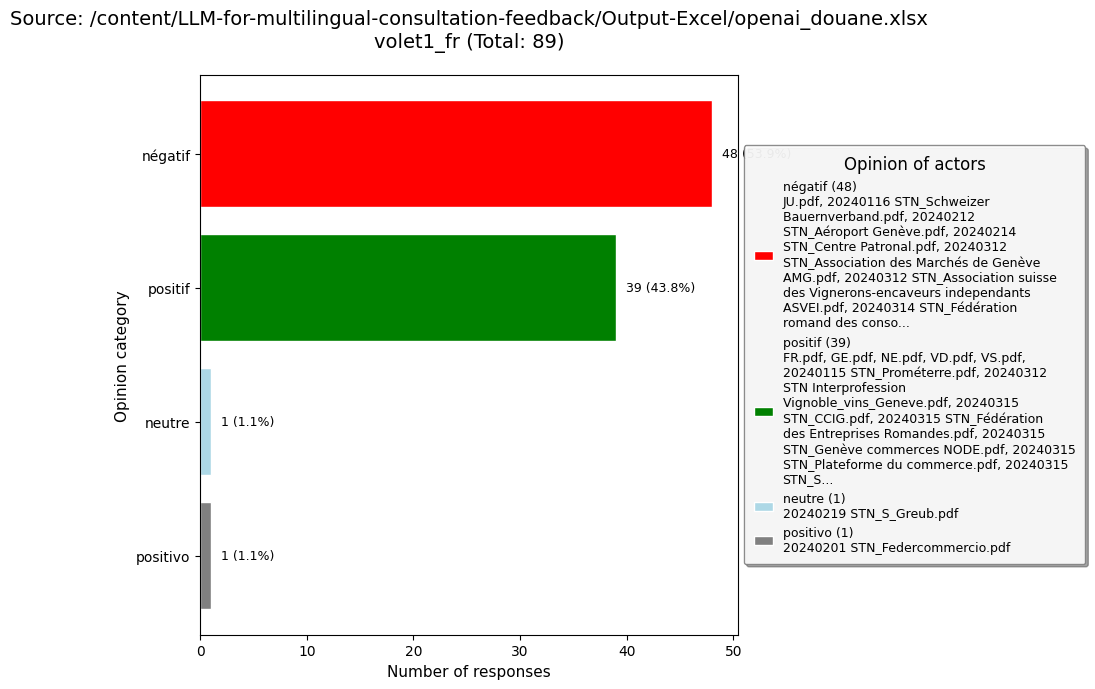


✅ Created zip archive: graphs_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import os
import shutil
from google.colab import files

# Directory containing the files to process
input_dir = '/content/LLM-for-multilingual-consultation-feedback/Output-Excel'

# Get all xlsx files in the directory
if os.path.exists(input_dir):
    files_to_process = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.xlsx')]
else:
    files_to_process = []
    print(f"Directory not found: {input_dir}")

output_dir = 'graphs_output'
os.makedirs(output_dir, exist_ok=True)

for file_name in files_to_process:
    print(f"\n--- Processing file: {file_name} ---")

    # 1) Load Data
    try:
        if file_name.endswith('.xlsx'):
            df = pd.read_excel(file_name)
        else:
            df = pd.read_csv(file_name)
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        continue

    # 2) Identify available columns dynamically
    # We only process the columns that actually exist in this file
    target_volets = ['volet1_fr', 'volet2_fr']
    present_volets = [v for v in target_volets if v in df.columns]

    if not present_volets:
        print(f"  No recognized volet columns ({target_volets}) found. Skipping.")
        continue

    for volet in present_volets:
        # 3) Counting and grouping actors
        counts = df[volet].dropna().value_counts()

        # Check if 'filename' column exists for actor details
        if 'filename' in df.columns:
            actors_by_cat = (
                df.dropna(subset=[volet])
                  .groupby(volet)['filename']
                  .apply(list)
                  .to_dict()
            )
        else:
            actors_by_cat = {}

        total_responses = counts.sum()
        if total_responses == 0:
            print(f"  No responses found for {volet}. Skipping.")
            continue

        # 4) Create Figure
        fig, ax = plt.subplots(figsize=(10, 7))

        # Colors
        color_map = {'négatif': 'red', 'positif': 'green', 'neutre': 'lightblue'}
        colors = [color_map.get(cat, 'gray') for cat in counts.index]

        # Horizontal Bar Chart
        bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1)

        ax.set_xlabel("Number of responses", fontsize=11)
        ax.set_ylabel("Opinion category", fontsize=11)
        ax.set_title(f"Source: {file_name}\n{volet} (Total: {total_responses})", fontsize=14, pad=20)

        # Most frequent on top
        ax.invert_yaxis()

        # Labels on bars
        vals = counts.values
        pcts = (vals / total_responses) * 100
        xpad = max(vals) * 0.02 if len(vals) else 0.5
        for i, (v, p) in enumerate(zip(vals, pcts)):
            ax.text(v + xpad, i, f"{v} ({p:.1f}%)", va='center', fontsize=9)

        # Legend Labels
        legend_labels = []
        for cat, n in counts.items():
            detail = ", ".join(actors_by_cat.get(cat, []))
            wrapped = textwrap.fill(detail, width=40) if detail else "No actors listed"
            if len(wrapped) > 300:
                wrapped = wrapped[:300] + "..."
            legend_labels.append(f"{cat} ({n})\n{wrapped}")

        # Legend
        ax.legend(
            bars,
            legend_labels,
            title="Opinion of actors",
            loc="center left",
            bbox_to_anchor=(1.0, 0.5),
            fontsize=9,
            title_fontsize=12,
            frameon=True,
            shadow=True,
            facecolor='white',
            framealpha=0.9,
            edgecolor='gray',
            handlelength=1.5,
            borderpad=0.8
        )

        plt.tight_layout()

        # Save and Show
        safe_name = os.path.splitext(os.path.basename(file_name))[0] # Fixed: Use os.path.basename to get just the filename
        out_path_pdf = os.path.join(output_dir, f"repartition_{safe_name}_{volet}.pdf")
        out_path_png = os.path.join(output_dir, f"repartition_{safe_name}_{volet}.png")

        fig.savefig(out_path_pdf, bbox_inches='tight')
        fig.savefig(out_path_png, bbox_inches='tight', dpi=300)

        print(f"✅ Saved graph to: {out_path_pdf}")
        print(f"✅ Saved graph to: {out_path_png}")
        plt.show()
        plt.close()

# Zip and download
shutil.make_archive('graphs_output', 'zip', output_dir)
print(f"\n✅ Created zip archive: graphs_output.zip")
files.download('graphs_output.zip')

In [ ]:
!apt-get update -y
!apt-get install -y pciutils lshw
!apt update && apt install -y lsof net-tools

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,992 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,908 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jam

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import os
import shutil
from google.colab import files

# --- Config ---
# Directory containing the files to process
input_dir = '/content/LLM-for-multilingual-consultation-feedback/Output-Excel'

# Get all xlsx files in the directory
if os.path.exists(input_dir):
    files_to_process = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.xlsx')]
else:
    files_to_process = []
    print(f"Directory not found: {input_dir}")

theme_col = 'category_fr'
output_root = './graphs'
os.makedirs(output_root, exist_ok=True)

# Load the embedding model ONCE
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

for file_name in files_to_process:
    print(f"\n--- Processing file: {file_name} ---")

    # Load data
    try:
        df = pd.read_excel(file_name)
    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        continue

    # --- 1. Prepare themes ---
    df = df.dropna(subset=[theme_col])
    if df.empty:
        print("No data after dropping NA in theme column, skipping.")
        continue

    themes = df[theme_col].tolist()

    # --- 2. Compute embeddings ---
    theme_embeddings = model.encode(themes)

    # --- 3. Pairwise cosine similarity ---
    similarity_matrix = cosine_similarity(theme_embeddings)
    np.fill_diagonal(similarity_matrix, 0)

    similarity_threshold_low = 0.80
    similarity_threshold_high = 0.9999

    # --- 4. Merge themes ---
    theme_map = {}

    for idx, theme in enumerate(themes):
        if theme in theme_map:
            continue

        similar_idxs = np.where(
            (similarity_matrix[idx] >= similarity_threshold_low) &
            (similarity_matrix[idx] <= similarity_threshold_high)
        )[0]

        candidates = [themes[i] for i in similar_idxs] + [theme]
        canonical = (
            df[df[theme_col].isin(candidates)][theme_col]
            .value_counts()
            .idxmax()
        )

        for candidate in candidates:
            theme_map[candidate] = canonical

    # Apply merging
    df['cleaned_theme'] = df[theme_col].map(theme_map)
    df['cleaned_theme'] = df['cleaned_theme'].fillna(df[theme_col])

    # Recount theme frequencies
    cleaned_counts = df['cleaned_theme'].value_counts()

    # Per-file output folder and basename
    base_name = os.path.splitext(os.path.basename(file_name))[0]
    file_output_dir = os.path.join(output_root, base_name)
    os.makedirs(file_output_dir, exist_ok=True)

    # ---------- PIE CHART: THEMES ONLY ----------
    fig, ax = plt.subplots(figsize=(10, 10))
    explode = [0.05] * len(cleaned_counts)

    wedges, texts, autotexts = ax.pie(
        cleaned_counts,
        autopct='%1.1f%%',
        startangle=140,
        explode=explode,
        pctdistance=0.75,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    ax.set(aspect="equal")
    ax.set_title(
        f"{base_name} – Distribution of thematics\nNumber of responses: {cleaned_counts.sum()}",
        fontsize=16,
        pad=30
    )

    legend_labels = [
        "\n".join(textwrap.wrap(cat, width=15))
        for cat in cleaned_counts.index
    ]

    legend = ax.legend(
        wedges,
        legend_labels,
        title="Thematics",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        ncol=3,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.8,
        edgecolor='gray',
        borderpad=1,
        handlelength=1.2,
        handletextpad=0.5,
        columnspacing=2.5,
        labelspacing=1.2
    )
    legend.get_frame().set_boxstyle('round,pad=0.5')

    plt.tight_layout()
    pie_only_path = os.path.join(file_output_dir, f"{base_name}_themes_pie.pdf")
    fig.savefig(pie_only_path, bbox_inches="tight")
    # Save as PNG
    fig.savefig(pie_only_path.replace('.pdf', '.png'), bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Saved pie (themes only): {pie_only_path}")

    # ---------- PIE CHART: THEMES + ACTORS ----------
    actors_by_cat = df.groupby('cleaned_theme')['filename'].apply(list)

    fig, ax = plt.subplots(figsize=(10, 10))
    wedges, texts, autotexts = ax.pie(
        cleaned_counts,
        autopct='%1.1f%%',
        startangle=140,
        explode=explode,
        pctdistance=0.75,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )

    ax.set(aspect="equal")
    ax.set_title(
        f"{base_name} – Distribution of thematics\nNumber of responses: {cleaned_counts.sum()}",
        fontsize=16,
        pad=30
    )

    def wrap_label_pie(cat):
        cat_wrapped = "\n".join(textwrap.wrap(cat, width=15))
        acteurs = actors_by_cat.get(cat, [])
        details_wrapped = "\n".join(textwrap.wrap(", ".join(acteurs), width=20))
        label = rf"{{{cat_wrapped}}} : {len(acteurs)}"
        if acteurs:
            label += "\n" + details_wrapped
        return label

    legend_labels = [wrap_label_pie(cat) for cat in cleaned_counts.index]

    legend = ax.legend(
        wedges,
        legend_labels,
        title="Thematics and actors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        ncol=3,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.8,
        edgecolor='gray',
        borderpad=1,
        handlelength=1.2,
        handletextpad=0.5,
        columnspacing=2.5,
        labelspacing=1.2
    )
    legend.get_frame().set_boxstyle('round,pad=0.5')

    plt.tight_layout()
    pie_actors_path = os.path.join(file_output_dir, f"{base_name}_themes_actors_pie.pdf")
    fig.savefig(pie_actors_path, bbox_inches="tight")
    # Save as PNG
    fig.savefig(pie_actors_path.replace('.pdf', '.png'), bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Saved pie (themes + actors): {pie_actors_path}")

    # ---------- BAR CHART: THEMES ONLY ----------
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(cleaned_counts.index, cleaned_counts.values, color=plt.cm.tab20.colors)

    ax.set_xlabel("Number of responses", fontsize=12)
    ax.set_ylabel("Thematics", fontsize=12)
    ax.set_title(
        f"Distribution of thematics\nNumber of responses: {cleaned_counts.sum()}",
        fontsize=16,
        pad=20
    )

    ax.invert_yaxis()

    for i, (value, name) in enumerate(zip(cleaned_counts.values, cleaned_counts.index)):
        ax.text(value + 0.5, i, str(value), va='center', fontsize=10)

    plt.tight_layout()
    bar_only_path = os.path.join(file_output_dir, f"{base_name}_themes_bar.pdf")
    fig.savefig(bar_only_path, bbox_inches="tight")
    # Save as PNG
    fig.savefig(bar_only_path.replace('.pdf', '.png'), bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Saved bar (themes only): {bar_only_path}")

    # ---------- BAR CHART: THEMES + ACTORS ----------
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(cleaned_counts.index, cleaned_counts.values, color=plt.cm.Paired.colors)

    ax.set_xlabel("Number of responses", fontsize=12)
    ax.set_ylabel("Themes", fontsize=12)
    ax.set_title(
        f"{base_name} – Distribution of thematics (with actors)\nNumber of responses: {cleaned_counts.sum()}",
        fontsize=16,
        pad=20
    )

    ax.invert_yaxis()

    def wrap_label_bar(cat):
        acteurs = actors_by_cat.get(cat, [])
        acteurs_str = ", ".join(acteurs)
        wrapped = "\n".join(textwrap.wrap(acteurs_str, width=40)) if acteurs_str else "No actors listed"
        return f"{cat} ({len(acteurs)} actors)\n{wrapped}"

    legend_labels = [wrap_label_bar(cat) for cat in cleaned_counts.index]

    legend = ax.legend(
        bars,
        legend_labels,
        title="Thematics and actors",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
        title_fontsize=12,
        ncol=1,
        frameon=True,
        shadow=True,
        facecolor='white',
        framealpha=0.9,
        edgecolor='gray',
        borderpad=1,
        handlelength=1.2,
        handletextpad=0.8,
        labelspacing=1.5
    )
    legend.get_frame().set_boxstyle('round,pad=0.5')

    plt.tight_layout()
    bar_actors_path = os.path.join(file_output_dir, f"{base_name}_themes_actors_bar.pdf")
    fig.savefig(bar_actors_path, bbox_inches="tight")
    # Save as PNG
    fig.savefig(bar_actors_path.replace('.pdf', '.png'), bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Saved bar (themes + actors): {bar_actors_path}")

# Zip and download
shutil.make_archive('graphs_all', 'zip', output_root)
print(f"\n✅ Created zip archive: graphs_all.zip")
files.download('graphs_all.zip')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


--- Processing file: /content/LLM-for-multilingual-consultation-feedback/Output-Excel/openai_imprescriptibility.xlsx ---
Saved pie (themes only): ./graphs/openai_imprescriptibility/openai_imprescriptibility_themes_pie.pdf
Saved pie (themes + actors): ./graphs/openai_imprescriptibility/openai_imprescriptibility_themes_actors_pie.pdf


/tmp/ipykernel_469/3430504992.py:224: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved bar (themes only): ./graphs/openai_imprescriptibility/openai_imprescriptibility_themes_bar.pdf


/tmp/ipykernel_469/3430504992.py:275: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


...

Saved bar (themes only): ./graphs/openai_douane/openai_douane_themes_bar.pdf


/tmp/ipykernel_469/3430504992.py:275: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved bar (themes + actors): ./graphs/openai_douane/openai_douane_themes_actors_bar.pdf

✅ Created zip archive: graphs_all.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>